# Irregular-food model prediction

This notebook first creates a normal randomized environment. After randomization, Python moves every primitive body in `all_food_body_names` below the scene and moves the two irregular STL bodies into the camera view. It then runs inference and displays only the RGB image and prediction overlay.

**No ground-truth heatmap or loss is computed anywhere in this notebook.**

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import mujoco
import numpy as np
import torch
import torch.nn.functional as F


def find_environment_directory():
    current_directory = Path.cwd().resolve()
    candidates = [
        current_directory,
        current_directory / "CODE" / "Enviornment",
        *[parent / "CODE" / "Enviornment" for parent in current_directory.parents],
    ]
    for candidate in candidates:
        if (
            (candidate / "enviornment.py").is_file()
            and (candidate / "Model").is_dir()
            and (candidate / "xml_models" / "world.xml").is_file()
        ):
            return candidate
    raise RuntimeError("Could not find CODE/Enviornment from the current notebook directory")


ENVIRONMENT_DIRECTORY = find_environment_directory()
if str(ENVIRONMENT_DIRECTORY) not in sys.path:
    sys.path.insert(0, str(ENVIRONMENT_DIRECTORY))

from Model.UNet.unet import UNet
from Model.UNet.tmp.UNET_MODEL_OVERFIT_2ND_ROUND.UNetV2Constants import UNetV2Constants
from enviornment import Enviornment
from enviornment_randomizer import Enviornment_Randomizer
from randomization_constants import Randomization_Constants

WORLD_XML_FILE = ENVIRONMENT_DIRECTORY / "xml_models" / "world.xml"
CHECKPOINT_DIRECTORY = (
    ENVIRONMENT_DIRECTORY
    / "Model"
    / "UNet"
    / "tmp"
    / "General_Attempt_Using_2nd_Overfit"
)
BEST_CHECKPOINT_FILE = CHECKPOINT_DIRECTORY / "best_UNet.pt"
LATEST_CHECKPOINT_FILE = CHECKPOINT_DIRECTORY / "latest_UNet.pt"
CHECKPOINT_FILE = BEST_CHECKPOINT_FILE if BEST_CHECKPOINT_FILE.is_file() else LATEST_CHECKPOINT_FILE

print(f"Environment directory: {ENVIRONMENT_DIRECTORY}")
print(f"Checkpoint: {CHECKPOINT_FILE}")

Environment directory: /Users/aadibhatia/self-feeder-env/CODE/Enviornment
Checkpoint: /Users/aadibhatia/self-feeder-env/CODE/Enviornment/Model/UNet/tmp/General_Attempt_Using_2nd_Overfit/best_UNet.pt


## Load the normal environment and trained model

In [2]:
if not CHECKPOINT_FILE.is_file():
    raise RuntimeError(f"Checkpoint not found: {CHECKPOINT_FILE}")

model_constants = UNetV2Constants()
randomization_constants = Randomization_Constants()
enviornment_randomizer = Enviornment_Randomizer()

env = Enviornment(
    xml_file=str(WORLD_XML_FILE),
    Enviornment_Randomizer=enviornment_randomizer,
    Randomization_Constants=randomization_constants,
    Model_Constants=model_constants,
)

model = UNet(
    in_channels=3,
    num_classes=1,
    checkpoint_dir=str(CHECKPOINT_DIRECTORY),
    learning_rate=model_constants.learning_rate,
)
model.load_state_dict(
    torch.load(CHECKPOINT_FILE, map_location=model.device, weights_only=True)
)
model.eval()

print(f"Loaded checkpoint on: {model.device}")

Created UNet on: mps


Loaded checkpoint on: mps


## Randomize normally, then replace the primitives in Python

The XML is not edited at runtime. The normal primitive bodies are moved below the scene only after `new_scene()` completes. The irregular bodies are deliberately not members of `all_food_body_names`, so normal randomization and label code never process them.

In [3]:
TEST_SEED = int(np.random.default_rng().integers(1_000_000, 10_000_000))
env.new_scene(seed=TEST_SEED)

# Remove every normal randomized primitive from view after randomization.
for primitive_body_name in randomization_constants.all_food_body_names:
    env.model.body(primitive_body_name).pos[2] = (
        randomization_constants.out_of_scene_z_coordinate
    )

# Move only the two irregular mesh bodies into the visible plate region.
irregular_body_positions = {
    "food_slice_concave_instance": np.array([-0.035, 0.000, 0.175]),
    "irregular_food_block_instance": np.array([0.025, 0.000, 0.175]),
}
for irregular_body_name, irregular_position in irregular_body_positions.items():
    env.model.body(irregular_body_name).pos[:] = irregular_position

mujoco.mj_forward(env.model, env.data)
rgb_observation = env.observation()

print(f"Scene seed: {TEST_SEED}")
print(f"RGB shape: {rgb_observation.shape}")
print("Primitive bodies moved out of scene:", len(randomization_constants.all_food_body_names))
print("Irregular bodies moved into scene:", list(irregular_body_positions))

Scene seed: 5813245
RGB shape: (1080, 1920, 3)
Primitive bodies moved out of scene: 12
Irregular bodies moved into scene: ['food_slice_concave_instance', 'irregular_food_block_instance']


## Prediction only — no target and no loss

In [4]:
model_input = (
    torch.from_numpy(rgb_observation)
    .permute(2, 0, 1)
    .unsqueeze(0)
    .float()
    / 255.0
)
model_input = F.interpolate(
    model_input,
    size=(model_constants.input_y_dim, model_constants.input_x_dim),
    mode="bilinear",
    align_corners=False,
).to(model.device)

with torch.no_grad():
    prediction_logits = model(model_input)
    predicted_heatmap = torch.sigmoid(prediction_logits)[0, 0].cpu().numpy()

predicted_peak_y, predicted_peak_x = np.unravel_index(
    np.argmax(predicted_heatmap),
    predicted_heatmap.shape,
)

print(f"Prediction shape: {predicted_heatmap.shape}")
print(f"Prediction range: {predicted_heatmap.min():.6f} to {predicted_heatmap.max():.6f}")
print(f"Strongest predicted pixel (x, y): ({predicted_peak_x}, {predicted_peak_y})")

Prediction shape: (144, 256)
Prediction range: 0.000000 to 0.924209
Strongest predicted pixel (x, y): (202, 81)


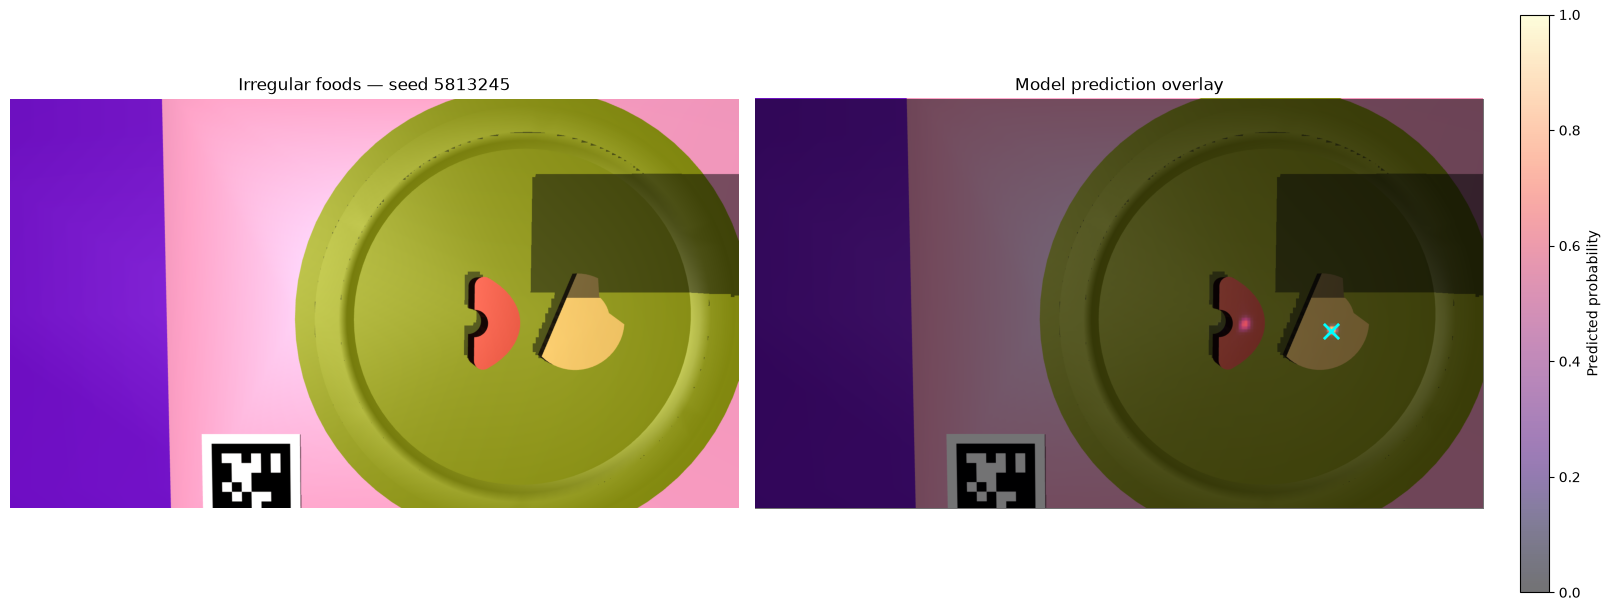

In [5]:
observation_height, observation_width = rgb_observation.shape[:2]
heatmap_height, heatmap_width = predicted_heatmap.shape

fig, axes = plt.subplots(1, 2, figsize=(16, 6), constrained_layout=True)

axes[0].imshow(rgb_observation)
axes[0].set_title(f"Irregular foods — seed {TEST_SEED}")
axes[0].axis("off")

axes[1].imshow(rgb_observation)
prediction_overlay = axes[1].imshow(
    predicted_heatmap,
    cmap="magma",
    alpha=0.55,
    vmin=0.0,
    vmax=1.0,
    origin="upper",
    extent=(0, observation_width, observation_height, 0),
)
axes[1].scatter(
    (predicted_peak_x + 0.5) * observation_width / heatmap_width,
    (predicted_peak_y + 0.5) * observation_height / heatmap_height,
    c="cyan",
    marker="x",
    s=120,
    linewidths=2,
)
axes[1].set_title("Model prediction overlay")
axes[1].axis("off")
fig.colorbar(prediction_overlay, ax=axes[1], label="Predicted probability")

plt.show()

## Outside-the-plate test

For a clean test, Python removes the irregular block so the concave slice is the only food-like object visible. The slice is moved fully beyond the plate's left edge, and the model runs inference again. This section still does not compute a target heatmap or loss.

Outside-food body position: [-0.17   0.     0.175]
Visible plate radius: 0.125 m
Food clearance beyond visible rim: 0.020 m
Outside-scene prediction range: 0.000000 to 0.004560
Strongest predicted pixel (x, y): (171, 64)


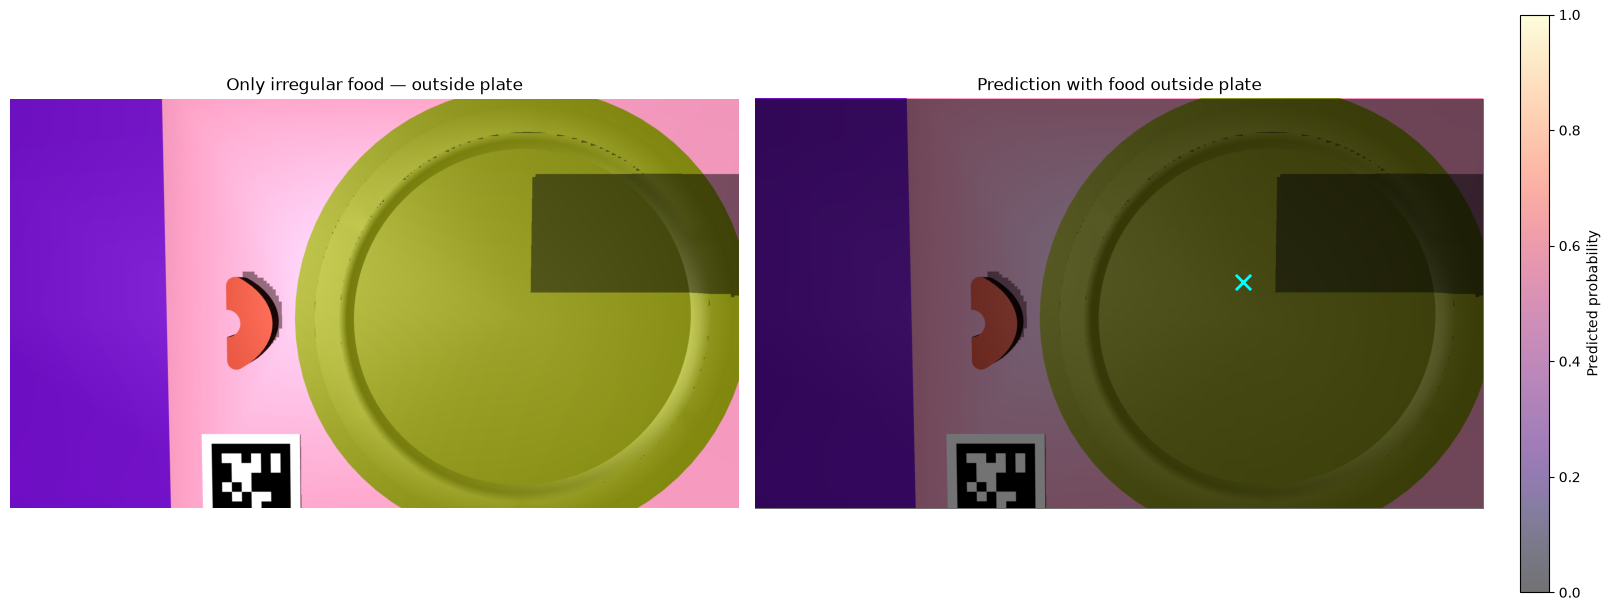

In [6]:
# Remove the on-plate irregular block so this test contains one food only.
env.model.body("irregular_food_block_instance").pos[2] = (
    randomization_constants.out_of_scene_z_coordinate
)

# The visible plate mesh has a 0.125 m outer radius. The slice extends about
# 0.025 m toward the plate, so its closest edge is -0.145 m: 0.020 m clear.
VISIBLE_PLATE_RADIUS = 0.125
OUTSIDE_PLATE_POSITION = np.array([-0.170, 0.000, 0.175])
env.model.body("food_slice_concave_instance").pos[:] = OUTSIDE_PLATE_POSITION
mujoco.mj_forward(env.model, env.data)

outside_rgb_observation = env.observation()
outside_model_input = (
    torch.from_numpy(outside_rgb_observation)
    .permute(2, 0, 1)
    .unsqueeze(0)
    .float()
    / 255.0
)
outside_model_input = F.interpolate(
    outside_model_input,
    size=(model_constants.input_y_dim, model_constants.input_x_dim),
    mode="bilinear",
    align_corners=False,
).to(model.device)

with torch.no_grad():
    outside_prediction_logits = model(outside_model_input)
    outside_predicted_heatmap = torch.sigmoid(outside_prediction_logits)[0, 0].cpu().numpy()

outside_peak_y, outside_peak_x = np.unravel_index(
    np.argmax(outside_predicted_heatmap),
    outside_predicted_heatmap.shape,
)

outside_height, outside_width = outside_rgb_observation.shape[:2]
outside_heatmap_height, outside_heatmap_width = outside_predicted_heatmap.shape

print(f"Outside-food body position: {OUTSIDE_PLATE_POSITION}")
print(f"Visible plate radius: {VISIBLE_PLATE_RADIUS:.3f} m")
print("Food clearance beyond visible rim: 0.020 m")
print(
    "Outside-scene prediction range: "
    f"{outside_predicted_heatmap.min():.6f} to {outside_predicted_heatmap.max():.6f}"
)
print(f"Strongest predicted pixel (x, y): ({outside_peak_x}, {outside_peak_y})")

fig, outside_axes = plt.subplots(1, 2, figsize=(16, 6), constrained_layout=True)

outside_axes[0].imshow(outside_rgb_observation)
outside_axes[0].set_title("Only irregular food — outside plate")
outside_axes[0].axis("off")

outside_axes[1].imshow(outside_rgb_observation)
outside_overlay = outside_axes[1].imshow(
    outside_predicted_heatmap,
    cmap="magma",
    alpha=0.55,
    vmin=0.0,
    vmax=1.0,
    origin="upper",
    extent=(0, outside_width, outside_height, 0),
)
outside_axes[1].scatter(
    (outside_peak_x + 0.5) * outside_width / outside_heatmap_width,
    (outside_peak_y + 0.5) * outside_height / outside_heatmap_height,
    c="cyan",
    marker="x",
    s=120,
    linewidths=2,
)
outside_axes[1].set_title("Prediction with food outside plate")
outside_axes[1].axis("off")
fig.colorbar(outside_overlay, ax=outside_axes[1], label="Predicted probability")

plt.show()